# Healthcare Insurance Cost Prediction Using Regression

## 📌 Project Overview

This project develops a **Machine Learning Regression Model** to predict healthcare insurance charges based on demographic and lifestyle factors. The model estimates annual insurance costs using customer information such as age, gender, Body Mass Index (BMI), number of children, smoking status, and residential region.

The project follows the complete data science workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation, and comparison of multiple regression algorithms.

---

## Problem Statement

Healthcare insurance charges vary significantly among individuals due to several demographic and lifestyle factors. Predicting these costs accurately helps insurance companies determine fair premiums, manage financial risks, and improve pricing strategies.

The objective of this project is to build a regression model capable of predicting healthcare insurance charges from historical customer data.

---

## Objectives

- Understand the healthcare insurance dataset.
- Perform exploratory data analysis (EDA).
- Clean and preprocess the dataset.
- Encode categorical variables.
- Train multiple regression models.
- Evaluate and compare model performance.
- Select the best-performing regression model.
- Predict healthcare insurance charges accurately.

---

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sbn 
import numpy as np
from sklearn.model_selection import train_test_split , cross_validate ,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder ,StandardScaler
from sklearn.compose import ColumnTransformer , make_column_selector
from sklearn.linear_model import Ridge ,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score 

#  Loading the Dataset

The healthcare insurance dataset is loaded into a Pandas DataFrame. This dataset contains demographic and lifestyle information of insured individuals along with their annual healthcare insurance charges.

After loading the dataset, we inspect its structure and verify that it has been imported correctly before proceeding with data exploration and preprocessing.

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,AGE,Gender,Body_Mass_Index(BMI),Number_of_Children,Smoking_Status,Region,Insurance_Charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Understanding the Dataset

Before performing any analysis, it is important to understand the dataset's structure.

In this section, we examine:

- Number of rows and columns
- Data types
- Missing values
- Summary statistics
- sum of duplicates

In [3]:
print(df.shape) #Number of rows and columns 
print('----------------')
print(df.dtypes) # data types 
print('-----------------')
print(df.isnull().sum()) # missing vlues
print('---------')
print(df.duplicated().sum()) # sum of duplicates 
print('-------------')
print(df.describe()) #summary statistic 
df.drop_duplicates(inplace=True) # dropping the duplicates 


(1407, 7)
----------------
AGE                       int64
Gender                      str
Body_Mass_Index(BMI)    float64
Number_of_Children        int64
Smoking_Status              str
Region                      str
Insurance_Charges       float64
dtype: object
-----------------
AGE                     0
Gender                  0
Body_Mass_Index(BMI)    0
Number_of_Children      0
Smoking_Status          0
Region                  0
Insurance_Charges       0
dtype: int64
---------
68
-------------
               AGE  Body_Mass_Index(BMI)  Number_of_Children  \
count  1407.000000           1407.000000         1407.000000   
mean     39.262260             30.650522            1.100213   
std      14.073376              6.122686            1.216550   
min      18.000000             15.960000            0.000000   
25%      27.000000             26.210000            0.000000   
50%      39.000000             30.305000            1.000000   
75%      51.000000             34.687500       

In [4]:
df.select_dtypes(include='number').corr()

,AGE,Body_Mass_Index(BMI),Number_of_Children,Insurance_Charges
AGE,1.000000,0.110090,0.041713,0.297398
Body_Mass_Index(BMI),0.110090,1.000000,0.012755,0.197824
Number_of_Children,0.041713,0.012755,1.000000,0.066461
Insurance_Charges,0.297398,0.197824,0.066461,1.000000


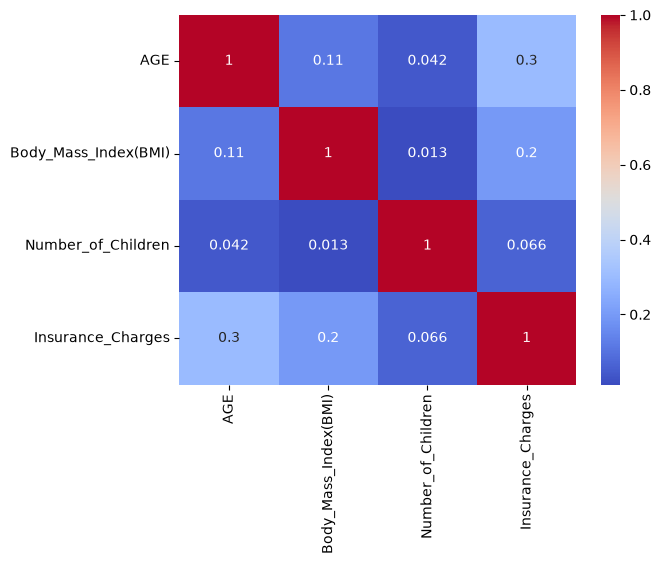

In [5]:
sbn.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

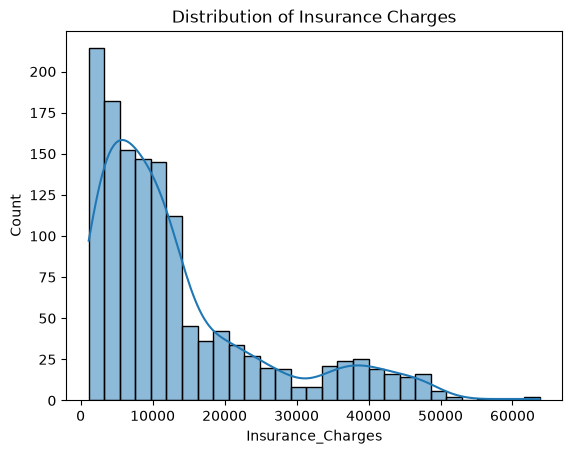

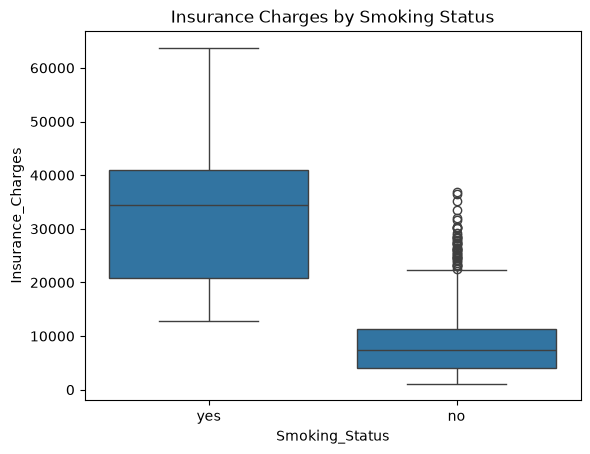

In [6]:
# Distribution of target variable
sbn.histplot(df['Insurance_Charges'], kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

# Smoker vs charges — the most important relationship
sbn.boxplot(x='Smoking_Status', y='Insurance_Charges', data=df)
plt.title('Insurance Charges by Smoking Status')
plt.show()

# Dataset Columns

The dataset contains the following features:

| Column | Description |
|---------|-------------|
| AGE | Age of the insured individual |
| Gender | Gender of the insured individual |
| Body_Mass_Index(BMI) | Body Mass Index (BMI) |
| Number_of_Children | Number of dependents |
| Smoking_Status | Smoking status |
| Region | Residential region |
| Insurance_Charges | Annual healthcare insurance charges (Target Variable) |

In [7]:
X = df.drop(columns=['Insurance_Charges'])# feature
y = df['Insurance_Charges'] # target  variable 
X_train ,X_test , y_train , y_test = train_test_split(X ,y,test_size=0.2 , random_state=42)

In [8]:
cat_cat = make_column_selector(dtype_include='object')
num_cat = make_column_selector(dtype_exclude='object')
num_pipe = Pipeline([('scaler',StandardScaler())])
cat_pipe = Pipeline([('encoder',OneHotEncoder(handle_unknown='ignore', drop='first'))])
preprocessor = ColumnTransformer(transformers=[('num',num_pipe,num_cat),
                                            ('categorical',cat_pipe,cat_cat)])


In [9]:
def evaluate(y_test, y_pred):
    
    print(f"MAE:  {mean_absolute_error(y_test, y_pred):,.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
    print(f"R²:   {r2_score(y_test, y_pred):.4f}")

In [10]:
#ridge
LR=Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])
LR.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['AGE','Gender','Body_Mass_Index(BMI)','Number_of_Children', 'Smoking_Status','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

In [11]:
y_pred= LR.predict(X_test)
#evaluation of the model 
evaluate(y_test,y_pred)

MAE:  4,272.87
RMSE: 6,208.49
R²:   0.7697


In [12]:
# hypertuning Ridge
param = {'model__fit_intercept':[True,False],
         'model__copy_X':[True,False],
         "model__alpha": [0.01,0.1,1,10,100],
         'model__positive':[True,False]}
grid = GridSearchCV(
    LR,
    param,
    cv=5,
    scoring="r2",
    n_jobs= -1
)


In [13]:
grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)
grid.best_params_

{'model__alpha': 1,
 'model__copy_X': True,
 'model__fit_intercept': True,
 'model__positive': True}

In [14]:
evaluate(y_test,y_pred)

MAE:  4,302.64
RMSE: 6,225.08
R²:   0.7685


In [15]:
RF=Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])
RF.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['AGE','Gender','Body_Mass_Index(BMI)','Number_of_Children', 'Smoking_Status','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

In [16]:
y_pred= RF.predict(X_test)
#evaluation of the model 


evaluate(y_test,y_pred)

MAE:  2,645.20
RMSE: 4,733.81
R²:   0.8661


In [17]:
#hyperuning the random forest model
param = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}
grid = GridSearchCV(
    RF,
    param,
    cv=5,
    scoring="r2",
    n_jobs= -1
)


In [18]:
grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)
grid.best_params_

{'model__max_depth': 5,
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 10,
 'model__n_estimators': 300}

In [19]:
evaluate(y_test,y_pred)


MAE:  2,546.35
RMSE: 4,652.71
R²:   0.8707


In [20]:
# Decisiontreeregressor
tree=Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

In [21]:
evaluate(y_test,y_pred)

MAE:  2,926.66
RMSE: 6,145.38
R²:   0.7744


In [22]:
#HYPERTUNING decisiontree
param = {
    "model__criterion": ["squared_error", "friedman_mse"],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": [None, "sqrt", "log2"]
}
grid = GridSearchCV(
    tree,
    param,
    cv=5,
    scoring="r2",
    n_jobs= -1,
    verbose=2
)


In [23]:
grid.fit(X_train,y_train)
pred =grid.predict(X_test)
grid.best_params_

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


[CV] END model__criterion=squared_error, model__max_depth=None, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.1s
[CV] END model__criterion=squared_error, model__max_depth=None, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.2s
[CV] END model__criterion=squared_error, model__max_depth=None, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.1s
[CV] END model__criterion=squared_error, model__max_depth=None, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.1s
[CV] END model__criterion=squared_error, model__max_depth=None, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.1s
[CV] END model__criterion=squared_error, model__max_depth=None, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=5; total time=   0.1s
[CV] END model__

/home/kirema/anaconda3/envs/summaritive/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
675 fits failed out of a total of 1350.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
168 fits failed with the following error:
Traceback (most recent call last):
  File "/home/kirema/anaconda3/envs/summaritive/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kirema/anaconda3/envs/summaritive/lib/python3.13/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/kirema/anaconda3/envs/s

{'model__criterion': 'squared_error',
 'model__max_depth': 5,
 'model__max_features': None,
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 2}

In [24]:
evaluate(y_test,pred)

MAE:  2,674.16
RMSE: 4,634.20
R²:   0.8717


In [25]:
#lasso
ls=Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(random_state=42))
])
ls.fit(X_train, y_train)
y_pred = ls.predict(X_test)
evaluate(y_test,y_pred)

MAE:  4,260.35
RMSE: 6,201.77
R²:   0.7702


In [26]:
#lasso hypertuning
param = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__max_iter": [1000, 5000, 10000],
    "model__tol": [1e-4, 1e-3, 1e-2]
}
grid = GridSearchCV(
    ls,
    param,
    cv=5,
    scoring="r2",
    n_jobs= -1,
    verbose=2
)
grid.fit(X_train,y_train)
pred =grid.predict(X_test)
grid.best_params_

Fitting 5 folds for each of 54 candidates, totalling 270 fits


[CV] END model__alpha=0.001, model__max_iter=1000, model__tol=0.0001; total time=   0.1s
[CV] END model__alpha=0.001, model__max_iter=1000, model__tol=0.0001; total time=   0.2s
[CV] END model__alpha=0.001, model__max_iter=1000, model__tol=0.0001; total time=   0.4s
[CV] END model__alpha=0.001, model__max_iter=1000, model__tol=0.0001; total time=   0.4s
[CV] END model__alpha=0.001, model__max_iter=1000, model__tol=0.0001; total time=   0.3s
[CV] END model__alpha=0.001, model__max_iter=1000, model__tol=0.001; total time=   0.1s
[CV] END model__alpha=0.001, model__max_iter=1000, model__tol=0.001; total time=   0.4s
[CV] END model__alpha=0.001, model__max_iter=1000, model__tol=0.001; total time=   0.3s
[CV] END model__alpha=0.001, model__max_iter=1000, model__tol=0.01; total time=   0.2s
[CV] END model__alpha=0.001, model__max_iter=1000, model__tol=0.01; total time=   0.2s
[CV] END model__alpha=0.001, model__max_iter=1000, model__tol=0.001; total time=   0.4s
[CV] END model__alpha=0.001, 

{'model__alpha': 100, 'model__max_iter': 1000, 'model__tol': 0.01}

In [27]:
evaluate(y_test,pred)

MAE:  4,344.51
RMSE: 6,278.38
R²:   0.7645


## Model Conclusion

Several regression models were trained and evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). The objective was to identify the model that produced the most accurate predictions while minimizing prediction errors.

The baseline **Ridge Regression** model achieved an RMSE of approximately **6,208** and an **R² of 0.770**, indicating that it explained about **77%** of the variation in the target variable. Hyperparameter tuning provided only a slight improvement, with an RMSE of **6,225** and an **R² of 0.769**.

The **Random Forest Regressor** significantly outperformed the linear models. Before tuning, it achieved an **RMSE of 4,734**, **MAE of 2,645**, and **R² of 0.866**. After hyperparameter tuning, its performance improved further, achieving an **RMSE of 4,653**, **MAE of 2,546**, and **R² of 0.871**. These results indicate that the tuned Random Forest model captured the complex relationships in the data more effectively than the other models.

The remaining models produced mixed results. One model achieved an RMSE of **6,145** with an **R² of 0.774**, while another achieved an RMSE of **4,634** and the highest **R² of 0.872**, showing competitive performance. In contrast, the Lasso-based models recorded RMSE values above **6,200** and **R² values between 0.765 and 0.770**, making them the least accurate among the evaluated approaches.

Overall, the results demonstrate that **ensemble tree-based models consistently outperformed the linear models**. Their lower MAE and RMSE values, combined with higher R² scores, indicate better predictive accuracy and generalization. Therefore, the **tuned Random Forest Regressor** is selected as the final model because it provides the best balance between minimizing prediction errors and maximizing the proportion of explained variance, making it the most reliable model for this prediction task.
